In [1]:
# Profile and CPU policy: keep this cell before numerical-library imports.
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
for variable in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
                 "VECLIB_MAXIMUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ[variable] = "1"

PROFILE = os.environ.get("TINYMML_PROFILE", "reduced").lower()
CUSTOM_CONFIG = {
    "train_samples": 1_000, "test_samples": 250, "epochs": 3,
    "batch_size": 32, "inference_repeats": 5,
}
PROFILE_CONFIGS = {
    "reduced": {"train_samples": 1_000, "test_samples": 250, "epochs": 3,
                "batch_size": 32, "inference_repeats": 5},
    "full": {"train_samples": 50_000, "test_samples": 10_000, "epochs": 5,
             "batch_size": 32, "inference_repeats": 10},
    "custom": CUSTOM_CONFIG,
}

def resolve_config(profile):
    if profile not in PROFILE_CONFIGS:
        raise ValueError("TINYMML_PROFILE must be 'reduced', 'full', or 'custom'")
    config = dict(PROFILE_CONFIGS[profile])
    limits = {"train_samples": 50_000, "test_samples": 10_000}
    for key, maximum in limits.items():
        if not isinstance(config[key], int) or not 10 <= config[key] <= maximum:
            raise ValueError(f"{key} must be an integer between 10 and {maximum}")
    for key in ("epochs", "batch_size", "inference_repeats"):
        if not isinstance(config[key], int) or config[key] <= 0:
            raise ValueError(f"{key} must be a positive integer")
    return config

for profile_name in PROFILE_CONFIGS:
    resolve_config(profile_name)
CONFIG = {**resolve_config(PROFILE), "seed": 42, "learning_rate": 1e-3}
CONFIG

{'train_samples': 1000,
 'test_samples': 250,
 'epochs': 3,
 'batch_size': 32,
 'inference_repeats': 5,
 'seed': 42,
 'learning_rate': 0.001}

# CIFAR-10 CNN: TinyMML vs Keras

Explore color images, train equivalent two-block convolutional networks, and compare classification quality and CPU performance. TinyMML uses NCHW; Keras uses NHWC.

In [2]:
from importlib.metadata import version
from io import BytesIO
from pathlib import Path
from time import perf_counter
import platform
import sys

ROOT = Path.cwd()
if not (ROOT / "tinymodel").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import pyarrow.parquet as pq
from IPython.display import Markdown, display
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from threadpoolctl import threadpool_limits

THREAD_LIMITER = threadpool_limits(limits=1)
import tensorflow as tf
import keras
tf.config.set_visible_devices([], "GPU")
tf.config.threading.set_intra_op_parallelism_threads(1)
tf.config.threading.set_inter_op_parallelism_threads(1)

import tinytensor as tt
import tinymodel as tm

np.random.seed(CONFIG["seed"])
tt.manual_seed(CONFIG["seed"])
keras.utils.set_random_seed(CONFIG["seed"])
assert tf.config.get_visible_devices("GPU") == []
CLASS_NAMES = ["airplane", "automobile", "bird", "cat", "deer",
               "dog", "frog", "horse", "ship", "truck"]

def stratified_subset(labels, count, seed):
    indices = np.arange(len(labels))
    if count == len(labels):
        return indices
    selected, _ = train_test_split(indices, train_size=count, stratify=labels, random_state=seed)
    return np.asarray(selected)

def cached_huggingface_cifar(split):
    files = {
        "train": ("train-00000-of-00001.parquet", "8428b53a88a11ac374111006708df51469e315a22ac6d66470afd9c78d2ae883"),
        "test": ("test-00000-of-00001.parquet", "841389e6f2d64f28bf17310e430aebac20ec3ba611a3c5e231dc93c645ce84de"),
    }
    filename, sha256 = files[split]
    origin = f"https://huggingface.co/datasets/uoft-cs/cifar10/resolve/main/plain_text/{filename}?download=true"
    return Path(keras.utils.get_file(
        fname=filename, origin=origin, file_hash=sha256,
        cache_dir=str(ROOT / "data"), cache_subdir="cifar10",
    ))

def load_cifar_subset(path, sample_count, seed):
    labels = pq.read_table(path, columns=["label"])["label"].to_numpy()
    indices = stratified_subset(labels, sample_count, seed)
    parquet = pq.ParquetFile(path)
    row_group_size = parquet.metadata.row_group(0).num_rows
    images = np.empty((sample_count, 32, 32, 3), dtype=np.uint8)
    groups = indices // row_group_size
    for row_group in np.unique(groups):
        output_positions = np.flatnonzero(groups == row_group)
        encoded = parquet.read_row_group(int(row_group), columns=["img"])["img"].to_pylist()
        for output_position in output_positions:
            local_row = int(indices[output_position] % row_group_size)
            images[output_position] = np.asarray(Image.open(BytesIO(encoded[local_row]["bytes"])).convert("RGB"))
    return images, labels[indices].astype(np.int64), indices

def one_hot(labels, classes=10):
    return np.eye(classes, dtype=np.float32)[np.asarray(labels)]

def probabilities(logits):
    shifted = logits - logits.max(axis=1, keepdims=True)
    exponentials = np.exp(shifted)
    return exponentials / exponentials.sum(axis=1, keepdims=True)

def benchmark_inference(predict, samples, repeats):
    predict()
    durations = []
    for _ in range(repeats):
        started = perf_counter(); predict(); durations.append(perf_counter() - started)
    median = float(np.median(durations))
    return 1_000 * median, samples / median

def markdown_table(rows, columns):
    header = "| " + " | ".join(columns) + " |"
    divider = "| " + " | ".join(["---"] * len(columns)) + " |"
    body = ["| " + " | ".join(str(row[column]) for column in columns) + " |" for row in rows]
    return "\n".join([header, divider, *body])

environment = {"profile": PROFILE, "platform": platform.platform(), "machine": platform.machine(),
               "logical CPUs": os.cpu_count(), "Python": platform.python_version(),
               "NumPy": np.__version__, "TensorFlow": tf.__version__, "Keras": keras.__version__,
               "scikit-learn": version("scikit-learn"), "TinyTensor CUDA": tt.cuda_available()}
display(Markdown("## Environment and active profile\n" + "\n".join(f"- **{k}:** {v}" for k, v in environment.items())))
display(CONFIG)

## Environment and active profile
- **profile:** reduced
- **platform:** macOS-26.5.1-arm64-arm-64bit-Mach-O
- **machine:** arm64
- **logical CPUs:** 8
- **Python:** 3.13.14
- **NumPy:** 2.4.3
- **TensorFlow:** 2.21.0
- **Keras:** 3.15.0
- **scikit-learn:** 1.9.0
- **TinyTensor CUDA:** False

{'train_samples': 1000,
 'test_samples': 250,
 'epochs': 3,
 'batch_size': 32,
 'inference_repeats': 5,
 'seed': 42,
 'learning_rate': 0.001}

## Load and explore CIFAR-10

Selected TinyMML NCHW: (1000, 3, 32, 32) / (250, 3, 32, 32)
Selected Keras NHWC: (1000, 32, 32, 3) / (250, 32, 32, 3)
Pixel mean/std after scaling: 0.473 / 0.252
Train class counts: [100, 100, 100, 100, 100, 100, 100, 100, 100, 100]


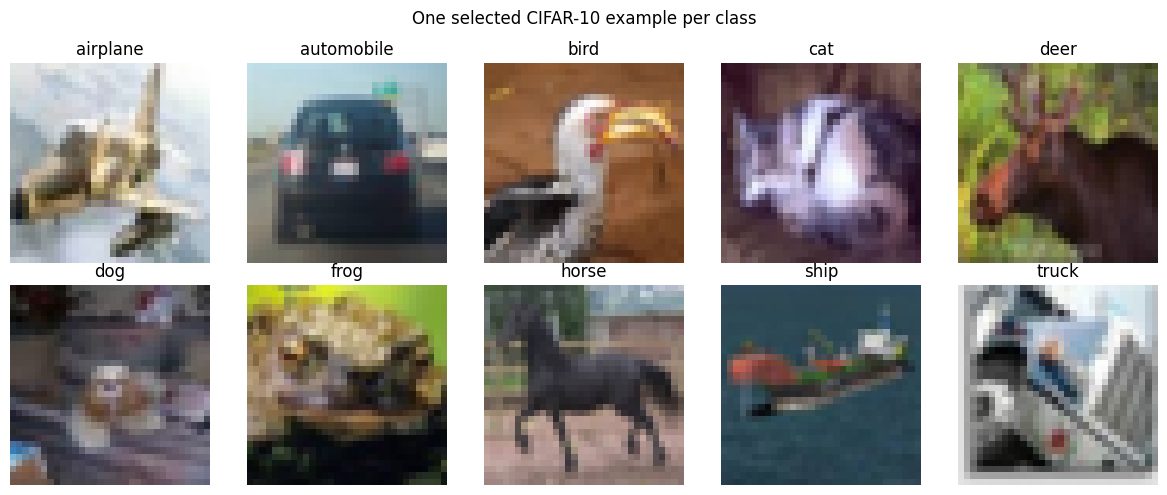

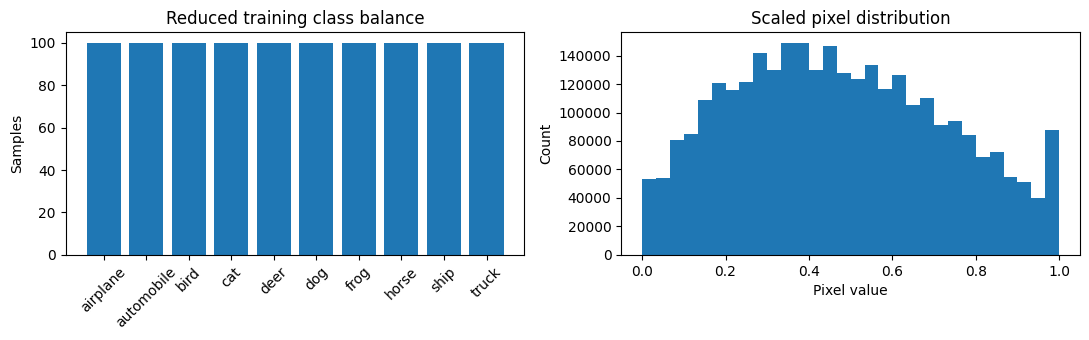

In [ ]:
train_path, test_path = cached_huggingface_cifar("train"), cached_huggingface_cifar("test")
x_train_uint8, y_train, train_indices = load_cifar_subset(train_path, CONFIG["train_samples"], CONFIG["seed"])
x_test_uint8, y_test, test_indices = load_cifar_subset(test_path, CONFIG["test_samples"], CONFIG["seed"] + 1)
x_train_keras = x_train_uint8.astype(np.float32) / 255.0
x_test_keras = x_test_uint8.astype(np.float32) / 255.0
x_train_tiny = np.ascontiguousarray(x_train_keras.transpose(0, 3, 1, 2))
x_test_tiny = np.ascontiguousarray(x_test_keras.transpose(0, 3, 1, 2))
y_train_one_hot, y_test_one_hot = one_hot(y_train), one_hot(y_test)

print(f"Selected TinyMML NCHW: {x_train_tiny.shape} / {x_test_tiny.shape}")
print(f"Selected Keras NHWC: {x_train_keras.shape} / {x_test_keras.shape}")
print(f"Pixel mean/std after scaling: {x_train_keras.mean():.3f} / {x_train_keras.std():.3f}")
print("Train class counts:", np.bincount(y_train, minlength=10).tolist())

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for label, axis in enumerate(axes.flat):
    image_index = np.flatnonzero(y_train == label)[0]
    axis.imshow(x_train_uint8[image_index])
    axis.set_title(CLASS_NAMES[label])
    axis.axis("off")
plt.suptitle("One selected CIFAR-10 example per class")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].bar(CLASS_NAMES, np.bincount(y_train, minlength=10))
axes[0].tick_params(axis="x", rotation=45)
axes[0].set(title="Reduced training class balance", ylabel="Samples")
axes[1].hist(x_train_keras.ravel(), bins=30)
axes[1].set(title="Scaled pixel distribution", xlabel="Pixel value", ylabel="Count")
plt.show()

## Matched CNNs

Both models use two stride-2 convolution blocks, dropout rates `0.1/0.2/0.3`, a 64-unit dense head, He initialization, Adam at `1e-3`, and logits categorical cross-entropy.

In [4]:
tt.manual_seed(CONFIG["seed"])
tiny_model = tm.Model([
    tm.Conv2D(16, 3, stride=2, padding=1, init="he"), tm.ReLU(), tm.Dropout(0.1),
    tm.Conv2D(32, 3, stride=2, padding=1, init="he"), tm.ReLU(), tm.Dropout(0.2),
    tm.Flatten(), tm.Linear(64, init="he"), tm.ReLU(), tm.Dropout(0.3), tm.Linear(10),
])
tiny_model.build(list(x_train_tiny.shape))
tiny_optimizer = tm.Adam(tiny_model.parameters(), lr=CONFIG["learning_rate"])
tiny_loss = tm.CrossEntropyLoss()

keras.utils.set_random_seed(CONFIG["seed"])
keras_model = keras.Sequential([
    keras.layers.Input(shape=(32, 32, 3)),
    keras.layers.Conv2D(16, 3, strides=2, padding="same", kernel_initializer="he_normal"),
    keras.layers.ReLU(), keras.layers.Dropout(0.1),
    keras.layers.Conv2D(32, 3, strides=2, padding="same", kernel_initializer="he_normal"),
    keras.layers.ReLU(), keras.layers.Dropout(0.2), keras.layers.Flatten(),
    keras.layers.Dense(64, kernel_initializer="he_normal"), keras.layers.ReLU(), keras.layers.Dropout(0.3),
    keras.layers.Dense(10),
])
keras_model.compile(optimizer=keras.optimizers.Adam(CONFIG["learning_rate"]),
                    loss=keras.losses.CategoricalCrossentropy(from_logits=True), metrics=["accuracy"])

model_info = [
    {"library": "TinyMML", "parameters": sum(p.size() for p in tiny_model.parameters()), "layout": "NCHW",
     "steps/epoch": int(np.ceil(len(x_train_tiny) / CONFIG["batch_size"]))},
    {"library": "Keras", "parameters": keras_model.count_params(), "layout": "NHWC",
     "steps/epoch": int(np.ceil(len(x_train_keras) / CONFIG["batch_size"]))},
]
display(Markdown(markdown_table(model_info, ["library", "parameters", "layout", "steps/epoch"])))

| library | parameters | layout | steps/epoch |
| --- | --- | --- | --- |
| TinyMML | 136874 | NCHW | 32 |
| Keras | 136874 | NHWC | 32 |

In [5]:
np.random.seed(CONFIG["seed"]); tt.manual_seed(CONFIG["seed"])
started = perf_counter()
tiny_history = tiny_model.fit(
    x_train_tiny, y_train_one_hot, epochs=CONFIG["epochs"], batch_size=CONFIG["batch_size"],
    optimizer=tiny_optimizer, loss_fn=tiny_loss, metric="accuracy", verbose=False,
)
tiny_train_seconds = perf_counter() - started
keras.utils.set_random_seed(CONFIG["seed"])
started = perf_counter()
keras_history = keras_model.fit(x_train_keras, y_train_one_hot, epochs=CONFIG["epochs"],
                                batch_size=CONFIG["batch_size"], shuffle=True, verbose=0)
keras_train_seconds = perf_counter() - started

tiny_test_loss, tiny_test_accuracy, tiny_logits = tiny_model.evaluate(
    x_test_tiny, y_test_one_hot, tiny_loss, batch_size=CONFIG["batch_size"], metric="accuracy", return_outputs=True,
)
keras_evaluation = keras_model.evaluate(x_test_keras, y_test_one_hot, batch_size=CONFIG["batch_size"], verbose=0, return_dict=True)
keras_logits = keras_model.predict(x_test_keras, batch_size=CONFIG["batch_size"], verbose=0)
tiny_probabilities, keras_probabilities = probabilities(tiny_logits), probabilities(keras_logits)
tiny_predictions, keras_predictions = tiny_probabilities.argmax(1), keras_probabilities.argmax(1)
tiny_latency, tiny_throughput = benchmark_inference(
    lambda: tiny_model.predict(x_test_tiny, batch_size=CONFIG["batch_size"]), len(x_test_tiny), CONFIG["inference_repeats"],
)
keras_latency, keras_throughput = benchmark_inference(
    lambda: keras_model.predict(x_test_keras, batch_size=CONFIG["batch_size"], verbose=0), len(x_test_keras), CONFIG["inference_repeats"],
)
results = [
    {"library": "TinyMML", "test loss": f"{tiny_test_loss:.4f}", "accuracy": f"{tiny_test_accuracy:.3f}",
     "macro F1": f"{f1_score(y_test, tiny_predictions, average='macro'):.3f}", "training s": f"{tiny_train_seconds:.2f}",
     "inference ms": f"{tiny_latency:.2f}", "samples/s": f"{tiny_throughput:.1f}"},
    {"library": "Keras", "test loss": f"{keras_evaluation['loss']:.4f}", "accuracy": f"{accuracy_score(y_test, keras_predictions):.3f}",
     "macro F1": f"{f1_score(y_test, keras_predictions, average='macro'):.3f}", "training s": f"{keras_train_seconds:.2f}",
     "inference ms": f"{keras_latency:.2f}", "samples/s": f"{keras_throughput:.1f}"},
]
display(Markdown("## Reduced-profile results\n" + markdown_table(results, list(results[0]))))

## Reduced-profile results
| library | test loss | accuracy | macro F1 | training s | inference ms | samples/s |
| --- | --- | --- | --- | --- | --- | --- |
| TinyMML | 2.2212 | 0.152 | 0.106 | 17.05 | 254.15 | 983.7 |
| Keras | 2.1089 | 0.232 | 0.134 | 1.66 | 52.37 | 4774.1 |

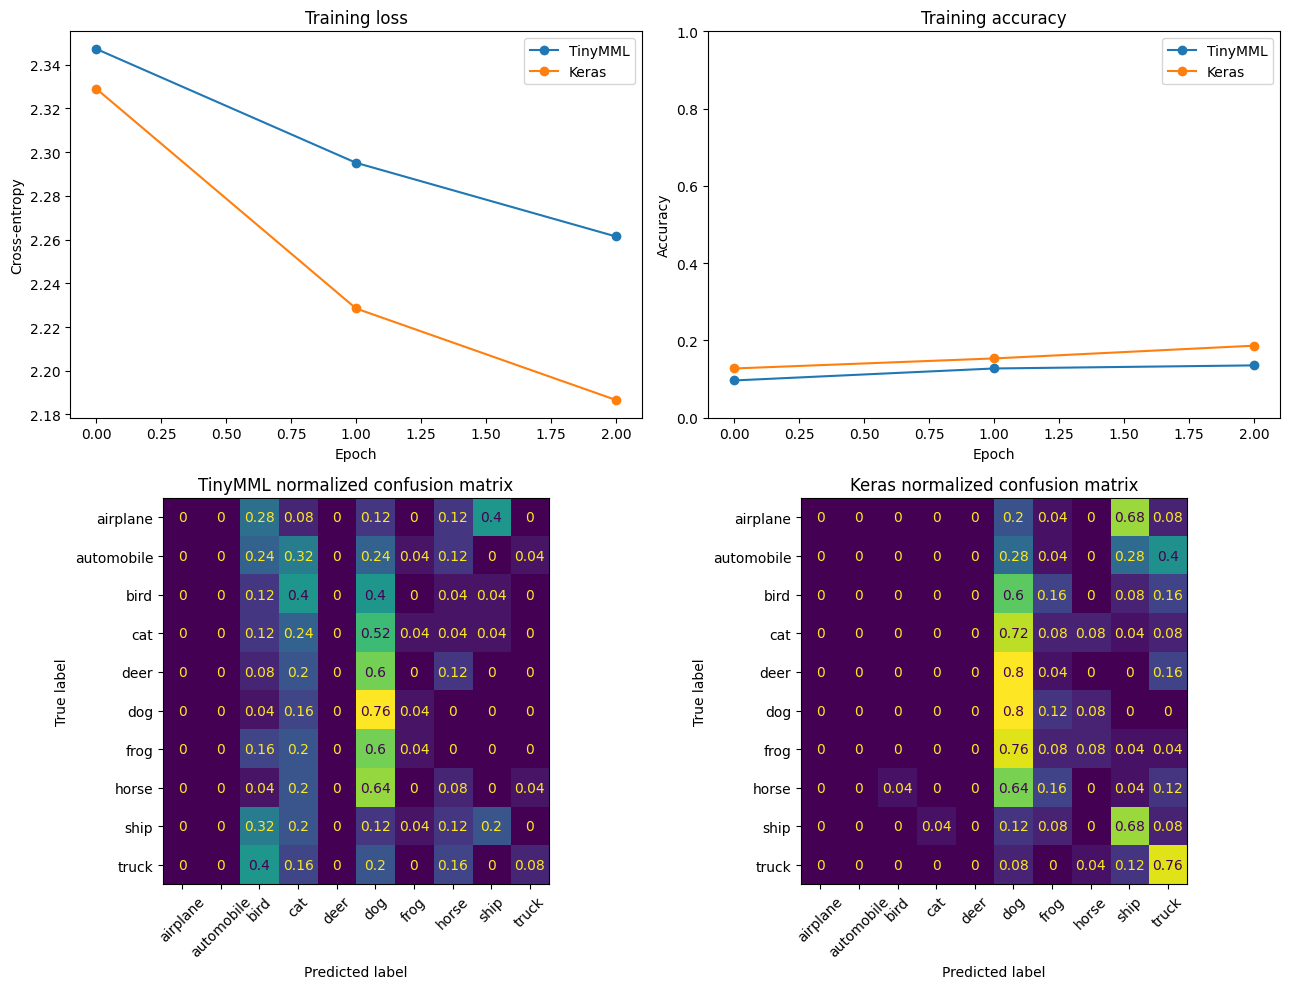

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes[0, 0].plot(tiny_history["loss"], marker="o", label="TinyMML")
axes[0, 0].plot(keras_history.history["loss"], marker="o", label="Keras")
axes[0, 0].set(title="Training loss", xlabel="Epoch", ylabel="Cross-entropy"); axes[0, 0].legend()
axes[0, 1].plot(tiny_history["metric"], marker="o", label="TinyMML")
axes[0, 1].plot(keras_history.history["accuracy"], marker="o", label="Keras")
axes[0, 1].set(title="Training accuracy", xlabel="Epoch", ylabel="Accuracy", ylim=(0, 1)); axes[0, 1].legend()
ConfusionMatrixDisplay.from_predictions(y_test, tiny_predictions, display_labels=CLASS_NAMES, normalize="true",
                                        ax=axes[1, 0], colorbar=False, xticks_rotation=45)
axes[1, 0].set_title("TinyMML normalized confusion matrix")
ConfusionMatrixDisplay.from_predictions(y_test, keras_predictions, display_labels=CLASS_NAMES, normalize="true",
                                        ax=axes[1, 1], colorbar=False, xticks_rotation=45)
axes[1, 1].set_title("Keras normalized confusion matrix")
plt.tight_layout(); plt.show()

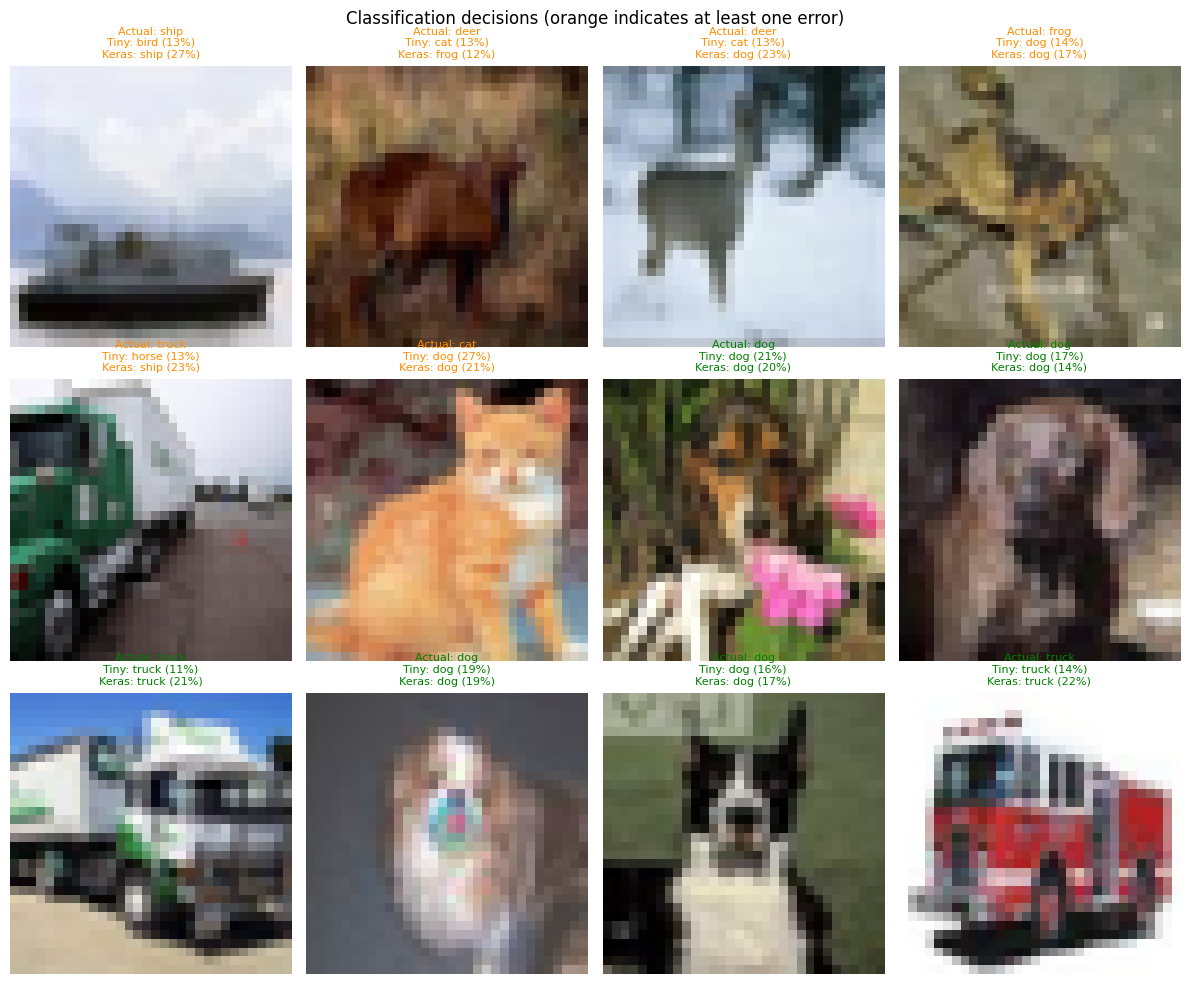

CIFAR-10 NOTEBOOK ACCEPTANCE PASSED


In [ ]:
wrong = np.flatnonzero((tiny_predictions != y_test) | (keras_predictions != y_test))[:6]
correct = np.flatnonzero((tiny_predictions == y_test) & (keras_predictions == y_test))[:12 - len(wrong)]
decision_indices = np.concatenate([wrong, correct])[:12]
fig, axes = plt.subplots(3, 4, figsize=(12, 10))
for axis, index in zip(axes.flat, decision_indices):
    axis.imshow(x_test_uint8[index])
    actual = y_test[index]
    color = "green" if tiny_predictions[index] == actual and keras_predictions[index] == actual else "darkorange"
    axis.set_title(
        f"Actual: {CLASS_NAMES[actual]}\nTiny: {CLASS_NAMES[tiny_predictions[index]]} ({tiny_probabilities[index].max():.0%})"
        f"\nKeras: {CLASS_NAMES[keras_predictions[index]]} ({keras_probabilities[index].max():.0%})", color=color, fontsize=8,
    )
    axis.axis("off")
for axis in axes.flat[len(decision_indices):]: axis.axis("off")
plt.suptitle("Classification decisions (orange indicates at least one error)")
plt.show()

assert np.isfinite(tiny_history["loss"]).all() and np.isfinite(keras_history.history["loss"]).all()
assert tiny_history["loss"][-1] < tiny_history["loss"][0]
assert keras_history.history["loss"][-1] < keras_history.history["loss"][0]
assert tiny_test_accuracy > 0.15, f"TinyMML CIFAR-10 accuracy too low: {tiny_test_accuracy:.3f}"
assert accuracy_score(y_test, keras_predictions) > 0.15
assert np.isfinite(tiny_probabilities).all() and np.isfinite(keras_probabilities).all()
np.testing.assert_allclose(tiny_probabilities.sum(1), 1.0, atol=1e-5)
np.testing.assert_allclose(keras_probabilities.sum(1), 1.0, atol=1e-5)
print("CIFAR-10 NOTEBOOK ACCEPTANCE PASSED")